<a href="https://colab.research.google.com/github/UltraGigaHero/EU_M_Math/blob/main/Chap03_Cm_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from pandas import DataFrame
import pandas as pd

import seaborn as sns

import requests, zipfile
from io import StringIO
import io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

r= requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

student_data_math = pd.read_csv('student-mat.csv', sep=';')

result = student_data_math.sort_values(['sex', 'G1'], ascending=[True, False])
print(result[['sex', 'G1']].to_string())
#一期目の数学データについて、男女別に昇順に並び替える

    sex  G1
374   F  19
198   F  18
286   F  18
293   F  18
359   F  18
260   F  17
303   F  17
65    F  16
69    F  16
91    F  16
120   F  16
139   F  16
182   F  16
200   F  16
222   F  16
226   F  16
324   F  16
335   F  16
338   F  16
363   F  16
3     F  15
59    F  15
271   F  15
291   F  15
302   F  15
314   F  15
376   F  15
378   F  15
15    F  14
39    F  14
56    F  14
109   F  14
143   F  14
167   F  14
169   F  14
195   F  14
215   F  14
256   F  14
298   F  14
305   F  14
311   F  14
329   F  14
336   F  14
369   F  14
16    F  13
87    F  13
122   F  13
176   F  13
224   F  13
230   F  13
237   F  13
238   F  13
287   F  13
313   F  13
315   F  13
320   F  13
345   F  13
348   F  13
360   F  13
372   F  13
38    F  12
50    F  12
130   F  12
133   F  12
184   F  12
212   F  12
229   F  12
267   F  12
275   F  12
282   F  12
292   F  12
300   F  12
309   F  12
323   F  12
331   F  12
356   F  12
357   F  12
364   F  12
46    F  11
51    F  11
74    F  11
77    F  11
93  

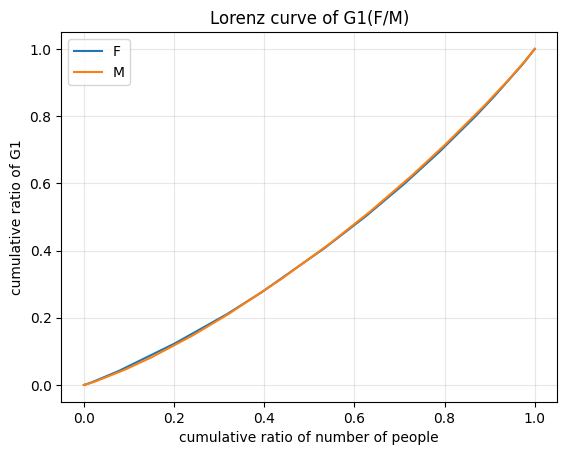

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from pandas import DataFrame
import pandas as pd

import seaborn as sns

import requests, zipfile
from io import StringIO
import io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

r= requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

student_data_math = pd.read_csv('student-mat.csv', sep=';')

sorted_df = student_data_math.sort_values(['sex', 'G1'], ascending=[True, True])
g_f = sorted_df.loc[sorted_df['sex'] == 'F', 'G1'].sort_values()
g_m = sorted_df.loc[sorted_df['sex'] == 'M', 'G1'].sort_values()
#男女別に昇順にデータを’sorted_df’に読み込み

#累積比率：各項目を大きい順（または時間順）に順次足し上げたとき、その累計値が全体の合計に対して何％を占めるかを示す割合のことです。

cum_people_f = np.arange(1, len(g_f) + 1) / len(g_f)
#女性の人数の累積比率を計算する
cum_g1_f = g_f.cumsum() / g_f.sum()
#女性の一期目の値の累積比率を計算する

cum_people_m = np.arange(1, len(g_m) + 1) / len(g_m)
cum_g1_m = g_m.cumsum() / g_m.sum()
#男性も同じ

plt.plot(np.r_[0, cum_people_f], np.r_[0, cum_g1_f], label='F')
plt.plot(np.r_[0, cum_people_m], np.r_[0, cum_g1_m], label='M')
#グラフに男性と女性が分けて作成する

plt.xlabel('cumulative ratio of number of people')
#人数の累積比率を横軸に

plt.ylabel('cumulative ratio of G1')
#一期目の値の累積比率を縦軸に

plt.title('Lorenz curve of G1(F/M)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
import numpy as np

import matplotlib.pyplot as plt

from pandas import DataFrame
import pandas as pd

import seaborn as sns

import requests, zipfile
from io import StringIO
import io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

r= requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

student_data_math = pd.read_csv('student-mat.csv', sep=';')

sorted_df = student_data_math.sort_values(['sex', 'G1'], ascending=[True, True])
g_f = sorted_df.loc[sorted_df['sex'] == 'F', 'G1'].sort_values()
g_m = sorted_df.loc[sorted_df['sex'] == 'M', 'G1'].sort_values()
#男女別に昇順にデータを’sorted_df’に読み込み

m_f = g_f.mean()
m_m = g_m.mean()
#G1の平均値を計算する

n_f = len(g_f)
n_m = len(g_m)
#男女のジニ係数のnを計算する

total_f = 0.0
for i in range(n_f):
    for j in range(n_f):
        total_f += abs(g_f.iloc[i] - g_f.iloc[j])
#'.iloc'を使った理由：直接にデータが所在しているの位置を読み取る

total_m = 0.0
for i in range(n_m):
    for j in range(n_m):
        total_m += abs(g_m.iloc[i] - g_m.iloc[j])


gini_f = total_f / (2 * n_f * n_f * m_f)
gini_m = total_m / (2 * n_m * n_m * m_m)

#計算法Bは以下となります
#S = np.abs(m_f[:, None] - m_f[None, :]).sum()
#gini_f = S / (2 * n_f**2 * n_f.mean())

print('G1のジニ係数（女）:', gini_f)
print('G1のジニ係数（男）:', gini_m)

G1のジニ係数（女）: 0.1723782950865341
G1のジニ係数（男）: 0.17197351667939903
